# 04 - Segmentation et mesures

## Objectif

Nettoyer le masque des régions suspectes et extraire des mesures simples : surface, nombre de régions et plus grande zone détectée.

In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import cv2
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import load_and_preprocess
from src.segmentation import contour_measurements, find_external_contours, region_summary, segment_dark_defects
from src.utils import build_image_index, display_images

## 1. Segmentation d'une image

La fonction `segment_dark_defects` applique le pipeline : contraste, seuillage inverse, suppression du bord et nettoyage morphologique.

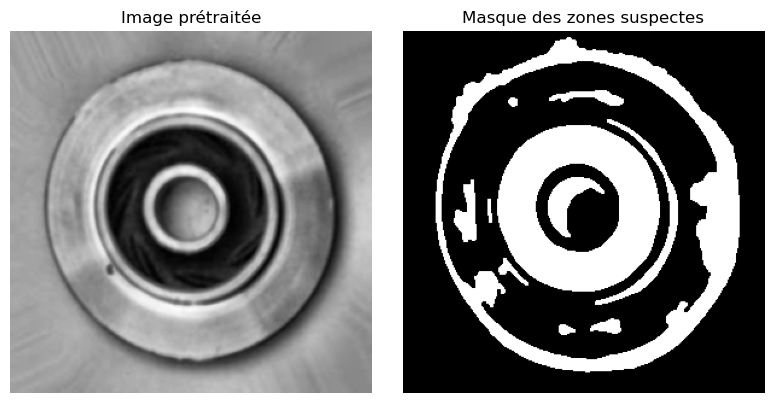

In [11]:
index_df = build_image_index()
if index_df.empty:
    raise FileNotFoundError("Aucune image trouvée dans data/raw/casting_data/.")

candidate = index_df[(index_df["split"] == "train") & (index_df["label_name"] == "Defective")]
sample_row = candidate.iloc[0] if not candidate.empty else index_df.iloc[0]

image = load_and_preprocess(sample_row["path"])
mask = segment_dark_defects(image)

display_images([image, mask], titles=["Image prétraitée", "Masque des zones suspectes"], cols=2, figsize=(8, 4))

## 2. Mesures globales

Ces mesures seront utilisées ensuite dans la décision par règles et dans les caractéristiques du SVM.

In [12]:
summary = region_summary(mask)
display(pd.DataFrame([summary]))

,defect_count,defect_area,defect_area_ratio,largest_defect_area,largest_defect_area_ratio
0,11.0,25769.0,0.286322,11283.0,0.125367


## 3. Mesures par contour

On peut aussi analyser chaque région détectée séparément.

,area,perimeter,x,y,width,height,circularity
0,53809.5,896.364567,27.0,5.0,252.0,278.0,0.841588


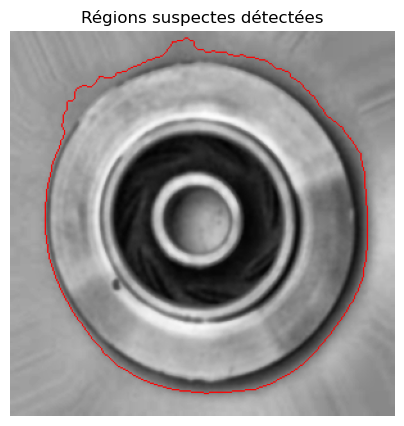

In [13]:
contours = find_external_contours(mask)
measurements = contour_measurements(contours)
display(pd.DataFrame(measurements).head(10))

overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.drawContours(overlay, contours, -1, (255, 0, 0), 1)

plt.figure(figsize=(5, 5))
plt.imshow(overlay)
plt.title("Régions suspectes détectées")
plt.axis("off")
plt.show()

## Conclusion

La segmentation fournit des informations quantitatives. Ces valeurs rendent possible une première classification par règles simples.